# CNN Architectures

In this notebook, we are going to implement a state-of-the-art convolutional neural network. You can use PyTorch, Keras, or TensorFlow for this purpose. However, you should provide a summary of the created network at the end. You have to implement an architecture between AlexNet and VGG19 and another architecture between Resnet50 and Inception v1.

## [VGG19 Architecture ](https://arxiv.org/pdf/1409.1556.pdf)

[![VGG19](https://drive.google.com/uc?export=view&id=1RVNnaJexXo1DmQGdLN-JIs6NwJDR9Ikb)](https://drive.google.com/uc?export=view&id=1RVNnaJexXo1DmQGdLN-JIs6NwJDR9Ikb)



## [AlexNet Architecture](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

[![AlexNet](https://drive.google.com/uc?export=view&id=1oQyk0IPqSsc5P2fAZXMplfcrEsHI_MUR)](https://drive.google.com/uc?export=view&id=1oQyk0IPqSsc5P2fAZXMplfcrEsHI_MUR)

## [Resnet50 Architecture](https://arxiv.org/abs/1512.03385)

[![Resnet50](https://drive.google.com/uc?export=view&id=1bMm3lrl8hQjVz1epH6WwEC24RFtMMUFo)](https://drive.google.com/uc?export=view&id=1bMm3lrl8hQjVz1epH6WwEC24RFtMMUFo)

## [Inception v3 Architecture](https://arxiv.org/abs/1512.00567v3)

[![Inception v1](https://drive.google.com/uc?export=view&id=1n-_IIBxsXviJRxH9Be6L2at6cnzzzuAq)](https://drive.google.com/uc?export=view&id=1n-_IIBxsXviJRxH9Be6L2at6cnzzzuAq)

## **First Implementation:**

In [1]:
import torch
import torch.nn as nn

class VGG(nn.Module):
    """
    Implementación manual de VGG19 siguiendo la arquitectura del paper
    'Very Deep Convolutional Networks for Large-Scale Image Recognition'
    (Simonyan & Zisserman, 2014).

    Atributos:
        features (nn.Sequential): 5 bloques convolucionales con filtros 3x3.
        avgpool (nn.AdaptiveAvgPool2d): Pooling adaptativo para salida fija de 7x7.
        classifier (nn.Sequential): 3 capas fully-connected para clasificación.
    """
    def __init__(self, num_classes=1000):
        super(VGG, self).__init__()
                                                                                            # Input: [batch, 3, 224, 224]
        self.features = nn.Sequential(
            # Bloque 1: 2 capas conv de 64 filtros 3x3
            nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),            # [batch, 64, 224, 224]
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),           # [batch, 64, 224, 224]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 64, 112, 112]

            # Bloque 2: 2 capas conv de 128 filtros 3x3
            nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),          # [batch, 128, 112, 112]
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 128, 112, 112]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 128, 56, 56]

            # Bloque 3: 4 capas conv de 256 filtros 3x3 (VGG19 tiene 4, VGG16 tiene 3)
            nn.Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 256, 56, 56]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 256, 28, 28]

            # Bloque 4: 4 capas conv de 512 filtros 3x3
            nn.Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 28, 28]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 512, 14, 14]

            # Bloque 5: 4 capas conv de 512 filtros 3x3
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),         # [batch, 512, 14, 14]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False),  # [batch, 512, 7, 7]
        )

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(7, 7))                            # [batch, 512, 7, 7]

        self.classifier = nn.Sequential(
            nn.Linear(in_features=512 * 7 * 7, out_features=4096, bias=True),               # [batch, 4096]
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Linear(in_features=4096, out_features=4096, bias=True),                       # [batch, 4096]
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5, inplace=False),
            nn.Linear(in_features=4096, out_features=num_classes, bias=True),                # [batch, num_classes]
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Instanciar y mostrar resumen de la arquitectura
my_vgg19 = VGG(num_classes=1000)
print(my_vgg19)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

## **Second Implementation:**

In [2]:
class Bottleneck(nn.Module):
    """
    Bloque Bottleneck para ResNet.
    Arquitectura: conv1x1 -> BN -> ReLU -> conv3x3 -> BN -> ReLU -> conv1x1 -> BN + skip -> ReLU
    El factor de expansión es 4 (el tercer conv1x1 multiplica los canales por 4).
    """
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        # Reducción de dimensionalidad: conv 1x1
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=(1, 1), stride=(1, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # Procesado espacial: conv 3x3 (aquí se aplica el stride)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=(3, 3), stride=(stride, stride), padding=(1, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # Expansión de canales: conv 1x1
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=(1, 1), stride=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Conexión residual (skip connection)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    """
    Implementación manual de ResNet.
    Basada en 'Deep Residual Learning for Image Recognition' (He et al., 2015).

    Para ResNet50 se usa layers=[3, 4, 6, 3] con bloques Bottleneck.
    Las conexiones residuales permiten entrenar redes muy profundas sin
    degradación del gradiente.
    """
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.inplanes = 64
                                                                                                    # Input: [batch, 3, 224, 224]
        # Stem: conv7x7 + BN + ReLU + MaxPool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)  # [batch, 64, 112, 112]
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)   # [batch, 64, 56, 56]

        # 4 stages de bloques residuales
        self.layer1 = self._make_layer(block, 64, layers[0])                                    # [batch, 256, 56, 56]
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)                         # [batch, 512, 28, 28]
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)                         # [batch, 1024, 14, 14]
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)                         # [batch, 2048, 7, 7]

        # Cabecera de clasificación
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))                                 # [batch, 2048, 1, 1]
        self.fc = nn.Linear(in_features=512 * block.expansion, out_features=num_classes, bias=True)  # [batch, num_classes]

    def _make_layer(self, block, planes, blocks, stride=1):
        """Construye un stage de bloques residuales."""
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=(1, 1), stride=(stride, stride), bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Bloques residuales
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Clasificación
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# ResNet50: 4 stages con [3, 4, 6, 3] bloques Bottleneck
my_resnet50 = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
print(my_resnet50)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Auxiliary code to check the created model.

In [3]:
from torchvision import models
alexnet = models.alexnet(weights=None)
vgg19 = models.vgg19(weights=None)
resnet50 = models.resnet50(weights=None)
inceptionv3 = models.inception_v3(weights=None, aux_logits=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


In [4]:
import io
import sys

def capture_model_print(model):
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    print(model)
    sys.stdout = old_stdout
    return buffer.getvalue()

# Verificar VGG19: comparar implementación manual vs torchvision
custom_vgg = capture_model_print(my_vgg19)
pytorch_vgg = capture_model_print(vgg19)

if custom_vgg == pytorch_vgg:
    print("VGG19: Los modelos tienen estructuras idénticas.")
else:
    print("VGG19: Las estructuras difieren.")

# Verificar ResNet50: comparar implementación manual vs torchvision
custom_res = capture_model_print(my_resnet50)
pytorch_res = capture_model_print(resnet50)

if custom_res == pytorch_res:
    print("ResNet50: Los modelos tienen estructuras idénticas.")
else:
    print("ResNet50: Las estructuras difieren.")

VGG19: Los modelos tienen estructuras idénticas.
ResNet50: Los modelos tienen estructuras idénticas.


# Dataset and Training

Now we are going to train one of the implemented networks. For this, we will use the CIFAR-10 dataset. This dataset is composed of 10 classes but we will only use 3.

In [5]:
#@title Imports
import glob
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
#@title Dataset

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1] range
])

def filter_indices_with_limits(dataset, class_sample_limits):
    indices = []
    class_counts = {cls: 0 for cls in class_sample_limits.keys()}
    for i in range(len(dataset)):
        _, label = dataset[i]
        class_name = dataset.classes[label]
        if class_name in class_sample_limits:
            if class_counts[class_name] < class_sample_limits[class_name]:
                indices.append(i)
                class_counts[class_name] += 1
            if all(class_counts[cls] >= limit for cls, limit in class_sample_limits.items()):
                break
    return indices


trainset = datasets.CIFAR10(root='CIFAR10_data/', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='CIFAR10_data/', train=False, download=True, transform=transform)

train_limits = {'airplane': 500, 'automobile': 500, 'bird': 50}
test_limits = {'airplane': 100, 'automobile': 100, 'bird': 100}

train_indices = filter_indices_with_limits(trainset, train_limits)
trainset_filtered = Subset(trainset, train_indices)

test_indices = filter_indices_with_limits(testset, test_limits)
testset_filtered = Subset(testset, test_indices)

trainloader = DataLoader(trainset_filtered, batch_size=64, shuffle=True)
testloader = DataLoader(testset_filtered, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:04<00:00, 39.5MB/s] 


## Data Augmentation

As you can see, we have a dataset that is not balanced. The `bird` class only has 50 samples, while `airplane` and `automobile` have 500. In this section, you will need to implement a data augmentation technique to solve this problem in our dataset.

You can find examples of different techniques at the following link:

1. [Getting started with transforms v2](https://pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_getting_started.html#sphx-glr-auto-examples-transforms-plot-transforms-getting-started-py)
2. [Transforming and augmenting images](https://pytorch.org/vision/stable/transforms.html)


### **Apply Data Augmentation**

In [7]:
from torch.utils.data import ConcatDataset

# Transformación con data augmentation agresiva para la clase minoritaria
augment_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Crear dataset CIFAR10 con las transformaciones de augmentation
trainset_augmented = datasets.CIFAR10(root='CIFAR10_data/', train=True, download=False, transform=augment_transform)

# Obtener los primeros 50 índices de la clase bird de forma eficiente
bird_class_idx = trainset_augmented.class_to_idx['bird']
bird_base_indices = [i for i, t in enumerate(trainset_augmented.targets) if t == bird_class_idx][:50]

# Repetir los índices 9 veces → 50 × 9 = 450 muestras augmentadas
# Cada repetición genera variaciones distintas gracias a las transformaciones aleatorias
augmented_bird_indices = bird_base_indices * 9
bird_augmented_subset = Subset(trainset_augmented, augmented_bird_indices)

# Dataset balanceado: original (500 airplane + 500 auto + 50 bird) + 450 bird augmentadas
trainset_balanced = ConcatDataset([trainset_filtered, bird_augmented_subset])
trainloader_balanced = DataLoader(trainset_balanced, batch_size=64, shuffle=True)

print(f"Dataset original (desbalanceado): {len(trainset_filtered)} muestras")
print(f"  - airplane: 500, automobile: 500, bird: 50")
print(f"Dataset balanceado: {len(trainset_balanced)} muestras")
print(f"  - airplane: 500, automobile: 500, bird: 50 + 450 aug = 500")

Dataset original (desbalanceado): 1050 muestras
  - airplane: 500, automobile: 500, bird: 50
Dataset balanceado: 1500 muestras
  - airplane: 500, automobile: 500, bird: 50 + 450 aug = 500


# Fine-Tunning

Now we are going to perform fine-tuning on the two architectures that have been implemented.

In [8]:
# Fine-tuning: Cargar pesos preentrenados de VGG19 en la implementación manual
model = VGG(num_classes=1000)
model.load_state_dict(models.vgg19(weights=None).state_dict())

# We have to modify the Classifier for 3 classes
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 3)
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
#@title Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [10]:
#@title Training

num_epochs = 3
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

Epoch 1, Loss: 0.9349576760740841
Epoch 2, Loss: 0.8317403933581184
Epoch 3, Loss: 0.7754188916262459


In [11]:
#@title Test the model

correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy of the model on the test images: {100 * correct / total}%")

Accuracy of the model on the test images: 48.0%


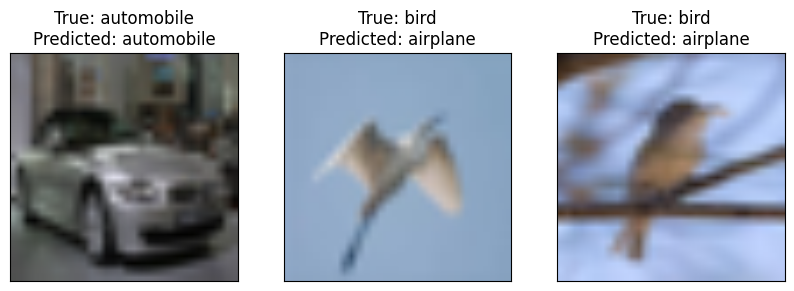

In [12]:
import matplotlib.pyplot as plt

model.eval()

# Get a batch of test images and labels
dataiter = iter(testloader)
images, labels = next(dataiter)

# Make predictions
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# Function to unnormalize and plot an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))

classes = trainset.classes[0:3]
fig = plt.figure(figsize=(10, 4))
for idx in range(3):
    ax = fig.add_subplot(1, 3, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"True: {classes[labels[idx]]}\nPredicted: {classes[predicted[idx]]}")

plt.show()

# **Questions**

1. Describe the techniques used to balance the dataset.



**Respuesta:**

Para equilibrar el dataset se ha utilizado data augmentation sobre la clase minoritaria (`bird`, 50 muestras) para igualarla con las clases mayoritarias (`airplane` y `automobile`, 500 muestras cada una).

Las técnicas de augmentation aplicadas son:

* RandomHorizontalFlip (p=0.5): Voltea horizontalmente la imagen con un 50% de probabilidad. Es válido porque un pájaro volteado sigue siendo un pájaro.
* RandomRotation (20°): Rota la imagen aleatoriamente hasta ±20 grados, generando variaciones en la orientación del objeto.
* ColorJitter (brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1): Modifica aleatoriamente las propiedades cromáticas de la imagen, simulando distintas condiciones de iluminación y ambientación.
* RandomAffine (translate=0.1, scale=0.9-1.1): Aplica traslaciones y escalados aleatorios, simulando diferentes posiciones y tamaños del objeto en el encuadre.

Se han generado 450 muestras augmentadas adicionales de `bird` repitiendo las 50 imágenes originales 9 veces con transformaciones aleatorias. Al ser estocásticas, cada repetición produce una imagen visualmente distinta, generando diversidad en el conjunto de entrenamiento. El resultado es un dataset balanceado de 1500 muestras totales (500 por clase).

2. Train both networks with balanced and unbalanced datasets. How does it affect the predictions? Display a confusion matrix for each case.


VGG19 - Dataset DESBALANCEADO
[VGG19-Desbalanceado] Epoch 1/10 - Train Loss: 0.9382 - Val Loss: 1.8230
[VGG19-Desbalanceado] Epoch 2/10 - Train Loss: 0.7984 - Val Loss: 1.4039
[VGG19-Desbalanceado] Epoch 3/10 - Train Loss: 0.7137 - Val Loss: 1.3790
[VGG19-Desbalanceado] Epoch 4/10 - Train Loss: 0.6653 - Val Loss: 1.2919
[VGG19-Desbalanceado] Epoch 5/10 - Train Loss: 0.6168 - Val Loss: 1.2022
[VGG19-Desbalanceado] Epoch 6/10 - Train Loss: 0.5781 - Val Loss: 1.2006
[VGG19-Desbalanceado] Epoch 7/10 - Train Loss: 0.5271 - Val Loss: 1.1501
[VGG19-Desbalanceado] Epoch 8/10 - Train Loss: 0.5083 - Val Loss: 1.1280
[VGG19-Desbalanceado] Epoch 9/10 - Train Loss: 0.4754 - Val Loss: 1.1666
[VGG19-Desbalanceado] Epoch 10/10 - Train Loss: 0.4465 - Val Loss: 1.0551


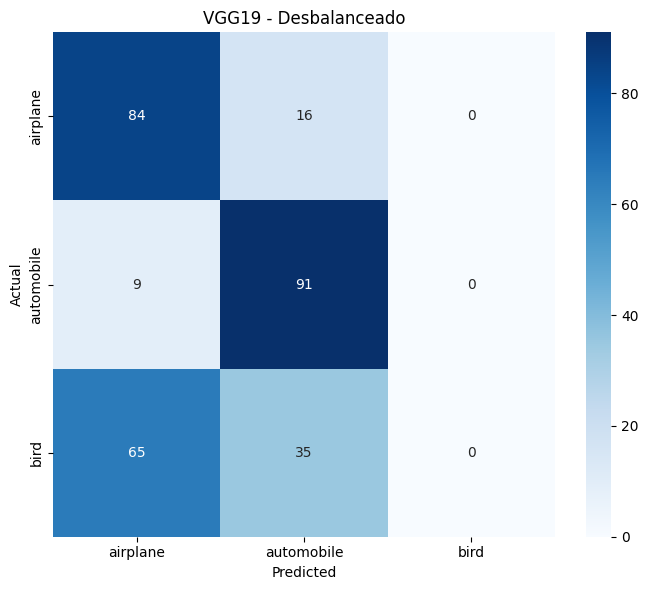


VGG19 - Dataset BALANCEADO
[VGG19-Balanceado] Epoch 1/10 - Train Loss: 1.0738 - Val Loss: 1.0517
[VGG19-Balanceado] Epoch 2/10 - Train Loss: 0.8721 - Val Loss: 1.0864
[VGG19-Balanceado] Epoch 3/10 - Train Loss: 0.6485 - Val Loss: 1.2189
[VGG19-Balanceado] Epoch 4/10 - Train Loss: 0.5476 - Val Loss: 1.1428
[VGG19-Balanceado] Epoch 5/10 - Train Loss: 0.4821 - Val Loss: 1.0794
[VGG19-Balanceado] Epoch 6/10 - Train Loss: 0.4529 - Val Loss: 0.9961
[VGG19-Balanceado] Epoch 7/10 - Train Loss: 0.4124 - Val Loss: 0.9074
[VGG19-Balanceado] Epoch 8/10 - Train Loss: 0.3776 - Val Loss: 1.0159
[VGG19-Balanceado] Epoch 9/10 - Train Loss: 0.3435 - Val Loss: 0.8787
[VGG19-Balanceado] Epoch 10/10 - Train Loss: 0.3404 - Val Loss: 0.9031


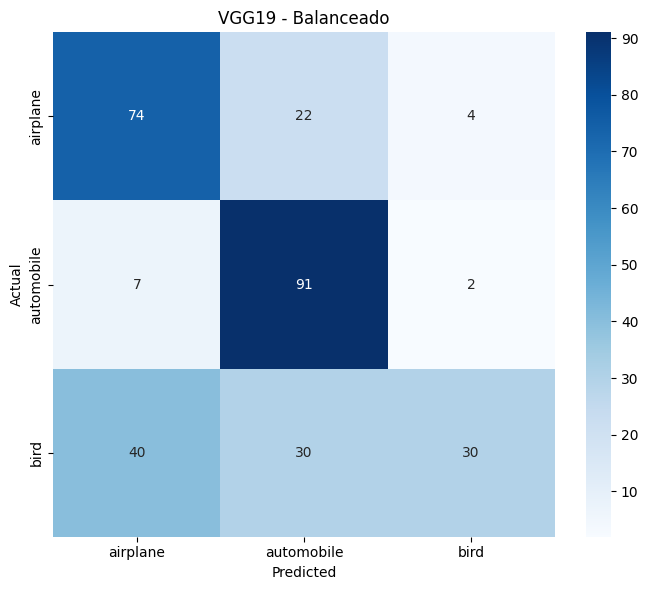


ResNet50 - Dataset DESBALANCEADO
[ResNet50-Desbalanceado] Epoch 1/10 - Train Loss: 0.9687 - Val Loss: 1.1222
[ResNet50-Desbalanceado] Epoch 2/10 - Train Loss: 0.8374 - Val Loss: 1.2704
[ResNet50-Desbalanceado] Epoch 3/10 - Train Loss: 0.7852 - Val Loss: 1.3092
[ResNet50-Desbalanceado] Epoch 4/10 - Train Loss: 0.7404 - Val Loss: 1.3108
[ResNet50-Desbalanceado] Epoch 5/10 - Train Loss: 0.7209 - Val Loss: 1.3188
[ResNet50-Desbalanceado] Epoch 6/10 - Train Loss: 0.6993 - Val Loss: 1.3514
[ResNet50-Desbalanceado] Epoch 7/10 - Train Loss: 0.6750 - Val Loss: 1.3791
[ResNet50-Desbalanceado] Epoch 8/10 - Train Loss: 0.6301 - Val Loss: 1.3730
[ResNet50-Desbalanceado] Epoch 9/10 - Train Loss: 0.6047 - Val Loss: 1.3641
[ResNet50-Desbalanceado] Epoch 10/10 - Train Loss: 0.5952 - Val Loss: 1.3153


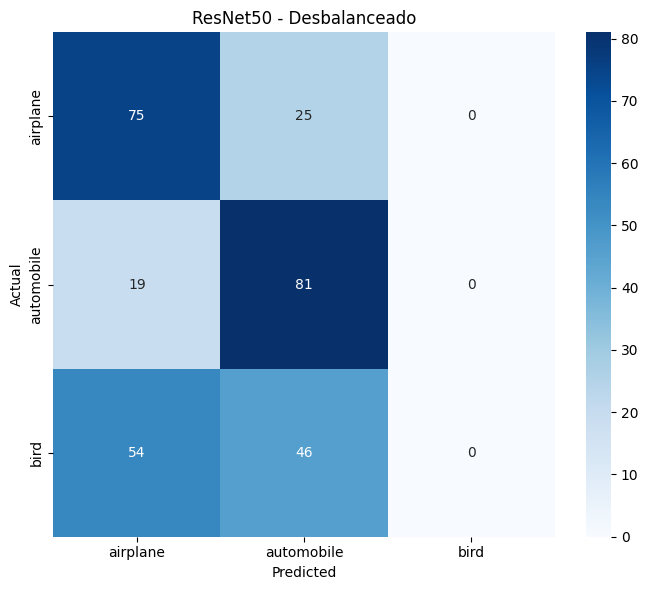


ResNet50 - Dataset BALANCEADO
[ResNet50-Balanceado] Epoch 1/10 - Train Loss: 0.9792 - Val Loss: 1.3443
[ResNet50-Balanceado] Epoch 2/10 - Train Loss: 0.8204 - Val Loss: 1.2462
[ResNet50-Balanceado] Epoch 3/10 - Train Loss: 0.7281 - Val Loss: 1.1659
[ResNet50-Balanceado] Epoch 4/10 - Train Loss: 0.6707 - Val Loss: 1.1248
[ResNet50-Balanceado] Epoch 5/10 - Train Loss: 0.6028 - Val Loss: 1.1228
[ResNet50-Balanceado] Epoch 6/10 - Train Loss: 0.5606 - Val Loss: 1.0570
[ResNet50-Balanceado] Epoch 7/10 - Train Loss: 0.5169 - Val Loss: 1.0077
[ResNet50-Balanceado] Epoch 8/10 - Train Loss: 0.4876 - Val Loss: 1.0099
[ResNet50-Balanceado] Epoch 9/10 - Train Loss: 0.4635 - Val Loss: 1.0358
[ResNet50-Balanceado] Epoch 10/10 - Train Loss: 0.4509 - Val Loss: 1.1149


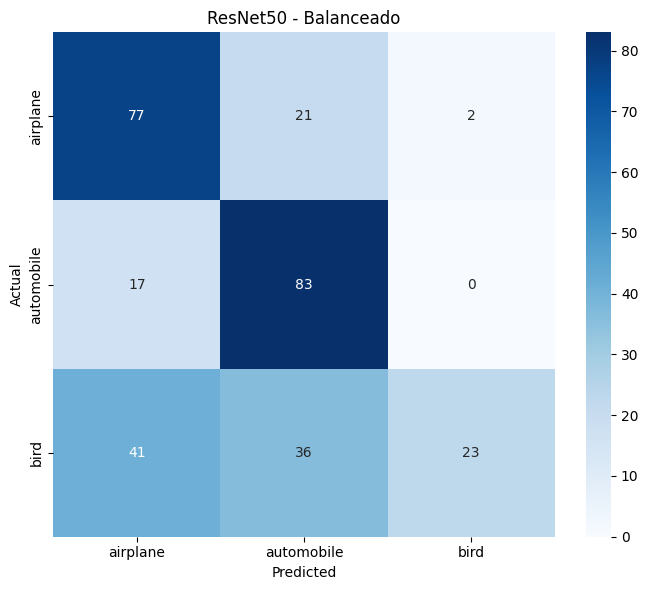

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def train_and_evaluate(model, train_loader, test_loader, num_epochs = 1, lr=1e-5, model_name="Model"):
    """Entrena un modelo y devuelve predicciones, targets y pérdidas por época."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_losses.append(val_loss / len(test_loader))

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_losses[-1]:.4f}")

    # Evaluación final
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), train_losses, val_losses


def plot_confusion(y_true, y_pred, class_names, title):
    """Muestra la matriz de confusión."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


classes = ['airplane', 'automobile', 'bird']
NUM_EPOCHS = 10

# ==================== VGG19 - Desbalanceado ====================
print("=" * 60)
print("VGG19 - Dataset DESBALANCEADO")
print("=" * 60)
vgg_unbal = VGG(num_classes=1000)
vgg_unbal.load_state_dict(models.vgg19(weights=None).state_dict())
vgg_unbal.classifier[6] = nn.Linear(4096, 3)

preds_vgg_u, targets_vgg_u, tl_vgg_u, vl_vgg_u = train_and_evaluate(
    vgg_unbal, trainloader, testloader, NUM_EPOCHS, model_name="VGG19-Desbalanceado")
plot_confusion(targets_vgg_u, preds_vgg_u, classes, "VGG19 - Desbalanceado")

# ==================== VGG19 - Balanceado ====================
print("\n" + "=" * 60)
print("VGG19 - Dataset BALANCEADO")
print("=" * 60)
vgg_bal = VGG(num_classes=1000)
vgg_bal.load_state_dict(models.vgg19(weights=None).state_dict())
vgg_bal.classifier[6] = nn.Linear(4096, 3)

preds_vgg_b, targets_vgg_b, tl_vgg_b, vl_vgg_b = train_and_evaluate(
    vgg_bal, trainloader_balanced, testloader, NUM_EPOCHS, model_name="VGG19-Balanceado")
plot_confusion(targets_vgg_b, preds_vgg_b, classes, "VGG19 - Balanceado")

# ==================== ResNet50 - Desbalanceado ====================
print("\n" + "=" * 60)
print("ResNet50 - Dataset DESBALANCEADO")
print("=" * 60)
res_unbal = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
res_unbal.load_state_dict(models.resnet50(weights=None).state_dict())
res_unbal.fc = nn.Linear(2048, 3)

preds_res_u, targets_res_u, tl_res_u, vl_res_u = train_and_evaluate(
    res_unbal, trainloader, testloader, NUM_EPOCHS, model_name="ResNet50-Desbalanceado")
plot_confusion(targets_res_u, preds_res_u, classes, "ResNet50 - Desbalanceado")

# ==================== ResNet50 - Balanceado ====================
print("\n" + "=" * 60)
print("ResNet50 - Dataset BALANCEADO")
print("=" * 60)
res_bal = ResNet(Bottleneck, [3, 4, 6, 3], num_classes=1000)
res_bal.load_state_dict(models.resnet50(weights=None).state_dict())
res_bal.fc = nn.Linear(2048, 3)

preds_res_b, targets_res_b, tl_res_b, vl_res_b = train_and_evaluate(
    res_bal, trainloader_balanced, testloader, NUM_EPOCHS, model_name="ResNet50-Balanceado")
plot_confusion(targets_res_b, preds_res_b, classes, "ResNet50 - Balanceado")

**Análisis:**

Estas matrices de confusión corresponden ya a la ejecución rehecha con 10 épocas. En una prueba anterior con solo 3 épocas los modelos quedaban demasiado infraentrenados y las conclusiones salían más pobres; por eso se decidió repetir el experimento con más entrenamiento, aunque el coste en tiempo fuese mayor. Con este nuevo resultado, la lectura cambia de forma clara.

Lo primero que se observa es que en los dos entrenamientos desbalanceados ninguna de las arquitecturas llega a predecir la clase `bird`. En VGG19 desbalanceado, los 100 ejemplos reales de `bird` se reparten entre `airplane` y `automobile` en una proporción de 65 y 35, mientras que en ResNet50 desbalanceado se distribuyen como 54 y 46. Es decir, en ambos casos la clase minoritaria desaparece por completo de la salida del modelo. La matriz deja ver con mucha claridad el sesgo inducido por el conjunto 500-500-50: la red aprende a resolver el problema casi como si solo hubiera dos clases relevantes.

Entre los dos casos desbalanceados, VGG19 muestra una matriz algo más ordenada. Clasifica correctamente 84 ejemplos de `airplane` y 91 de `automobile`, con menos confusión cruzada entre ambas clases que ResNet50, que se queda en 75 y 81 aciertos respectivamente. Por tanto, incluso ignorando `bird`, VGG19 organiza mejor la separación entre las dos clases dominantes, mientras que ResNet50 presenta una frontera más inestable también entre las categorías mayoritarias.

El cambio importante aparece al introducir el dataset balanceado. En VGG19 balanceado ya no desaparece la clase `bird`: ahora se clasifican correctamente 30 de sus 100 ejemplos. ResNet50 balanceado muestra un mismo salto en esa clase, con 23 aciertos. Este detalle es central, porque indica que el balanceo no aporta una mejora superficial, sino que corrige un fallo estructural que estaba presente en ambos modelos, la anulación completa de la clase minoritaria.

En VGG19, al balancear, `airplane` pasa de 84 a 74 aciertos, mientras `automobile` se mantiene en 91. En ResNet50, `airplane` mejora de 75 a 77, igual que en `automobile` que sube ligeramente de 81 a 83. Dicho de otra forma, el balanceo redistribuye la capacidad del modelo para que `bird` entre de verdad en la predicción, sin destruir el comportamiento sobre las clases principales.

La conclusión que permiten extraer las matrices es bastante firme; sin balanceo, ambas arquitecturas colapsan hacia las clases frecuentes y expulsan a `bird` de la decisión; con balanceo, las dos recuperan esa clase y construyen una separación mucho más realista del problema. Aun así, `bird` sigue siendo la categoría más difícil, porque incluso en los casos balanceados continúa acumulando muchos errores hacia `airplane` y `automobile`. Por tanto, el aumento a 10 épocas corrige la visión excesivamente negativa de la primera prueba, pero también confirma que la dificultad de la clase minoritaria no desaparece solo con entrenar más tiempo.

3. Generate graphs to compare the performance of the implemented networks on the different datasets, focusing on metrics such as training/validation loss, sensitivity, specificity, f1-measure ...

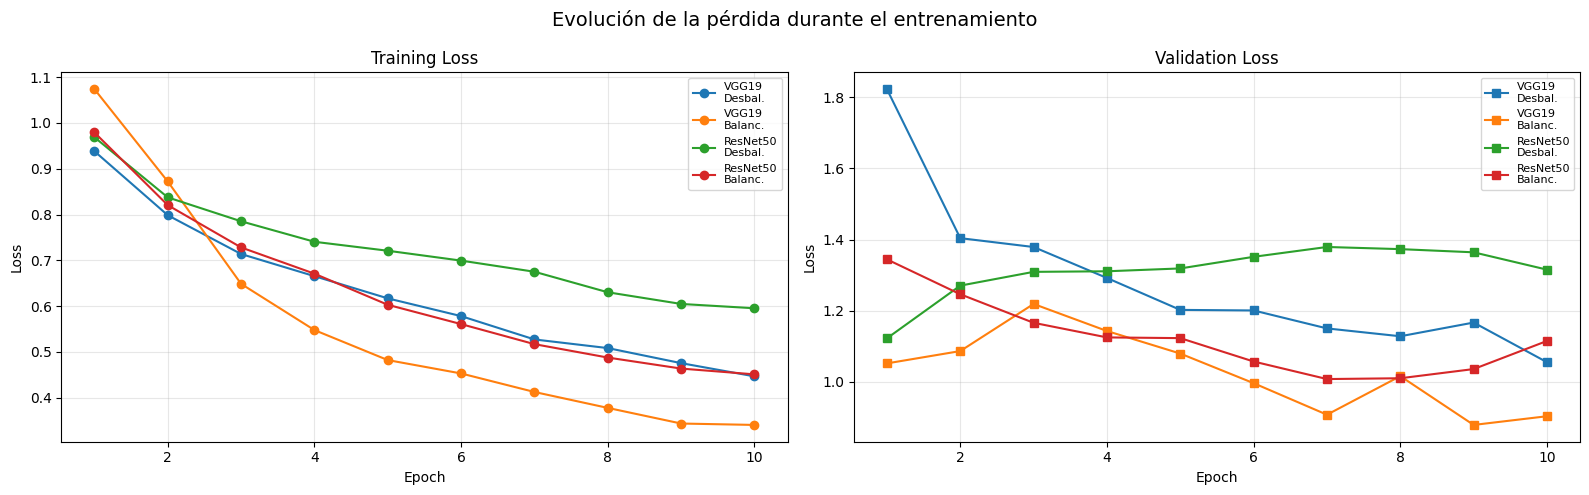

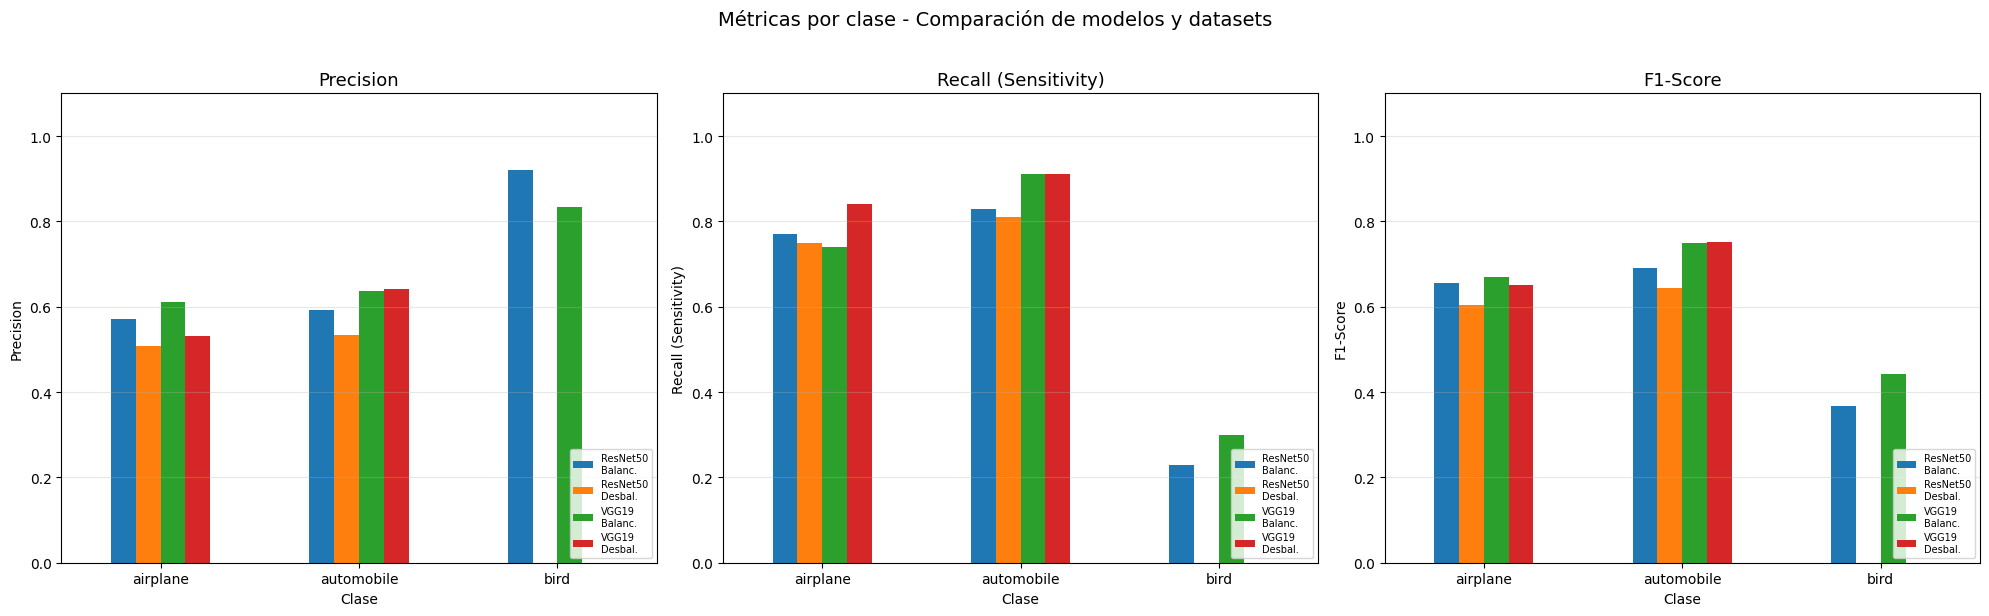

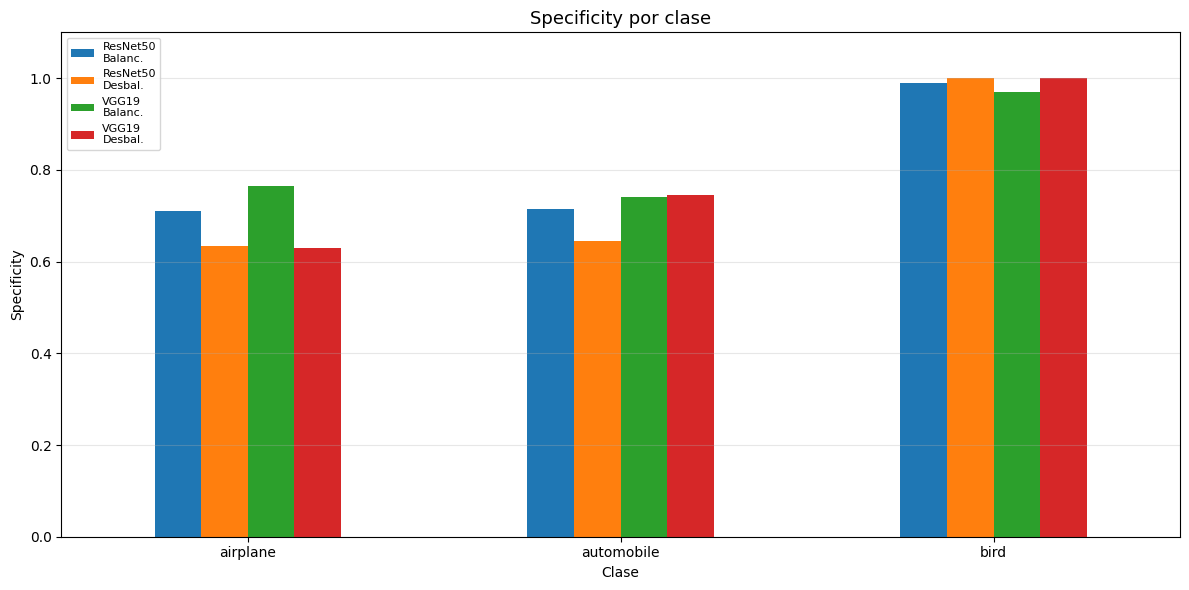

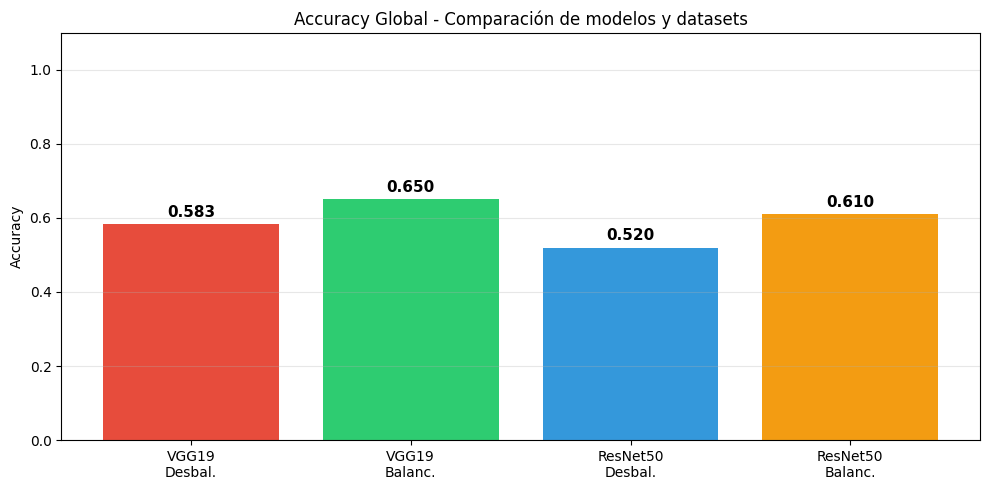


RESUMEN DE MÉTRICAS

--- VGG19 Desbal. ---


,precision,recall,f1-score,support
label,,,,
airplane,0.5316,0.8400,0.6512,100
automobile,0.6408,0.9100,0.7521,100
bird,0.0000,0.0000,0.0000,100
accuracy,,,0.5833,300
macro avg,0.3908,0.5833,0.4677,300
weighted avg,0.3908,0.5833,0.4677,300



--- VGG19 Balanc. ---


,precision,recall,f1-score,support
label,,,,
airplane,0.6116,0.7400,0.6697,100
automobile,0.6364,0.9100,0.7490,100
bird,0.8333,0.3000,0.4412,100
accuracy,,,0.6500,300
macro avg,0.6938,0.6500,0.6199,300
weighted avg,0.6938,0.6500,0.6199,300



--- ResNet50 Desbal. ---


,precision,recall,f1-score,support
label,,,,
airplane,0.5068,0.7500,0.6048,100
automobile,0.5329,0.8100,0.6429,100
bird,0.0000,0.0000,0.0000,100
accuracy,,,0.5200,300
macro avg,0.3466,0.5200,0.4159,300
weighted avg,0.3466,0.5200,0.4159,300



--- ResNet50 Balanc. ---


,precision,recall,f1-score,support
label,,,,
airplane,0.5704,0.7700,0.6553,100
automobile,0.5929,0.8300,0.6917,100
bird,0.9200,0.2300,0.3680,100
accuracy,,,0.6100,300
macro avg,0.6944,0.6100,0.5717,300
weighted avg,0.6944,0.6100,0.5717,300


In [14]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
from IPython.display import display
import pandas as pd

# Almacenar todos los resultados
results = {
    'VGG19\nDesbal.': (preds_vgg_u, targets_vgg_u, tl_vgg_u, vl_vgg_u),
    'VGG19\nBalanc.': (preds_vgg_b, targets_vgg_b, tl_vgg_b, vl_vgg_b),
    'ResNet50\nDesbal.': (preds_res_u, targets_res_u, tl_res_u, vl_res_u),
    'ResNet50\nBalanc.': (preds_res_b, targets_res_b, tl_res_b, vl_res_b),
}

# ==================== Gráfica 1: Training & Validation Loss ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, (_, _, tl, vl) in results.items():
    axes[0].plot(range(1, len(tl)+1), tl, marker='o', label=name)
    axes[1].plot(range(1, len(vl)+1), vl, marker='s', label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss'); axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.suptitle('Evolución de la pérdida durante el entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()

# ==================== Gráfica 2: Precision, Recall (Sensitivity), F1-Score por clase ====================
metrics_data = []
for name, (preds, targets, _, _) in results.items():
    precision, recall, f1, _ = precision_recall_fscore_support(targets, preds, average=None, labels=[0, 1, 2], zero_division=0)
    for i, cls in enumerate(classes):
        metrics_data.append({
            'Modelo': name, 'Clase': cls,
            'Precision': precision[i],
            'Recall (Sensitivity)': recall[i],
            'F1-Score': f1[i]
        })

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, metric in enumerate(['Precision', 'Recall (Sensitivity)', 'F1-Score']):
    ax = axes[idx]
    pivot = metrics_df.pivot(index='Clase', columns='Modelo', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(metric, fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Métricas por clase - Comparación de modelos y datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==================== Gráfica 3: Specificity por clase ====================
spec_data = []
for name, (preds, targets, _, _) in results.items():
    cm_temp = confusion_matrix(targets, preds, labels=[0, 1, 2])
    for i, cls in enumerate(classes):
        tn = cm_temp.sum() - cm_temp[i, :].sum() - cm_temp[:, i].sum() + cm_temp[i, i]
        fp = cm_temp[:, i].sum() - cm_temp[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        spec_data.append({'Modelo': name, 'Clase': cls, 'Specificity': specificity})

spec_df = pd.DataFrame(spec_data)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_spec = spec_df.pivot(index='Clase', columns='Modelo', values='Specificity')
pivot_spec.plot(kind='bar', rot=0, ax=ax)
ax.set_title('Specificity por clase', fontsize=13)
ax.set_ylabel('Specificity')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Gráfica 4: Accuracy global ====================
fig, ax = plt.subplots(figsize=(10, 5))
accs = {name: accuracy_score(targets, preds) for name, (preds, targets, _, _) in results.items()}
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax.bar(accs.keys(), accs.values(), color=colors)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Global - Comparación de modelos y datasets')
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, accs.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Tabla resumen ====================
def classification_report_to_df(targets, preds, classes):
    report = classification_report(
        targets,
        preds,
        target_names=classes,
        digits=4,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for cls in classes:
        rows.append({
            'label': cls,
            'precision': f"{report[cls]['precision']:.4f}",
            'recall': f"{report[cls]['recall']:.4f}",
            'f1-score': f"{report[cls]['f1-score']:.4f}",
            'support': int(report[cls]['support'])
        })

    total_support = int(sum(report[cls]['support'] for cls in classes))
    rows.append({
        'label': 'accuracy',
        'precision': '',
        'recall': '',
        'f1-score': f"{report['accuracy']:.4f}",
        'support': total_support
    })

    for avg_label in ['macro avg', 'weighted avg']:
        rows.append({
            'label': avg_label,
            'precision': f"{report[avg_label]['precision']:.4f}",
            'recall': f"{report[avg_label]['recall']:.4f}",
            'f1-score': f"{report[avg_label]['f1-score']:.4f}",
            'support': int(report[avg_label]['support'])
        })

    return pd.DataFrame(rows).set_index('label')

print("\n" + "=" * 80)
print("RESUMEN DE MÉTRICAS")
print("=" * 80)
for name, (preds, targets, _, _) in results.items():
    print(f"\n--- {name.replace(chr(10),' ')} ---")
    summary_df = classification_report_to_df(targets, preds, classes)
    display(summary_df)

**Análisis comparativo:**

Las gráficas permiten ver con más perspectiva lo que ya sugerían las matrices. En la prueba inicial con 3 épocas los modelos estaban todavía demasiado verdes y la comparación quedaba sesgada por el infraentrenamiento. Con 10 épocas ya se aprecia una tendencia más estable, y el resultado principal es claro: VGG19 con dataset balanceado sigue siendo la mejor configuración, pero ResNet50 balanceado mejora mucho más de lo que parecía en la ejecución anterior.

Si se observan primero las curvas de pérdida, VGG19 balanceado es la configuración que converge de forma más limpia. Termina con la training loss más baja y también con la menor validation loss del conjunto. Aunque aquí esa "validation" se está calculando sobre test y no sobre un conjunto independiente, la comparación relativa sigue siendo útil: esa configuración es la que muestra el ajuste más sólido durante el entrenamiento.

Las métricas globales refuerzan esa lectura. VGG19 pasa de 0.583 a 0.65 de accuracy al balancear, mientras que ResNet50 sube de 0.52 a 0.61 El efecto del balanceo, por tanto, no es marginal: mejora a ambas arquitecturas y además reduce bastante la distancia entre ellas. Esto cambia de forma importante la interpretación inicial, porque ResNet50 balanceado ya no aparece como un modelo claramente descolgado, sino como una alternativa bastante competitiva.

Las métricas por clase explican de dónde sale esa mejora. En sensibilidad, los dos modelos desbalanceados tienen recall 0 para `bird`, lo que confirma su desaparición práctica. Al balancear, ambos elevan el recall de `bird` hasta en el caso de VGG 0.44. Esto sigue siendo una cifra modesta, pero basta para demostrar que la clase minoritaria deja de estar anulada. A partir de ahí aparecen diferencias finas: VGG19 balanceado mantiene mejor el rendimiento de `automobile`, mientras que ResNet50 balanceado mejora de forma mas contundente que VGG respecto a sus versiones desbalanceadas, esto es gracias a corregir parte de su sesgo previo.

La precisión, el F1 y la especificidad completan la interpretación. VGG19 balanceado ofrece el mejor equilibrio general entre clases, y por eso queda primero en rendimiento agregado. ResNet50 balanceado, sin embargo, muestra un matiz interesante: cuando predice `bird`, suele hacerlo con bastante limpieza, de modo que su problema está más en la cobertura que en la pureza de la clase. Además, la especificidad alta de `bird` en los modelos desbalanceados no debe leerse como una fortaleza, sino como una consecuencia artificial de que casi nunca predicen esa clase. Solo en los modelos balanceados esa métrica empieza a tener una interpretación más útil al combinarse con un recall ya no nulo.

En conjunto, el ranking queda ahora bastante definido: VGG19 balanceado es la mejor opción, ResNet50 balanceado ocupa una segunda posición cercana, VGG19 desbalanceado queda por detrás y ResNet50 desbalanceado sigue siendo el caso más flojo. La conclusión de fondo es que aumentar a 10 épocas era necesario para evaluar de verdad el comportamiento de las redes y que el balanceo no es una mejora secundaria, sino una condición casi obligatoria para obtener resultados mínimamente razonables sobre la clase minoritaria.